# WiDS Datathon 2026 — Exploratory Data Analysis
**Problem:** Predict P(wildfire threatens evacuation zone) at 12h / 24h / 48h / 72h horizons  
**Metric:** 0.3 × C-index + 0.7 × (1 − Weighted Brier Score)

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from sklearn.feature_selection import mutual_info_classif
from lifelines import KaplanMeierFitter
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', '{:.4g}'.format)
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 200)

SEED = 42
DATA_DIR = 'Data/'

In [3]:
train = pd.read_csv(DATA_DIR + 'train.csv')
test  = pd.read_csv(DATA_DIR + 'test.csv')
sub   = pd.read_csv(DATA_DIR + 'sample_submission.csv')
meta  = pd.read_csv(DATA_DIR + 'metaData.csv')

FEATURES = [c for c in train.columns if c not in ['event_id', 'time_to_hit_hours', 'event']]

FEATURE_GROUPS = {
    'Temporal Coverage': ['num_perimeters_0_5h', 'dt_first_last_0_5h', 'low_temporal_resolution_0_5h'],
    'Growth': ['area_first_ha', 'area_growth_abs_0_5h', 'area_growth_rel_0_5h',
               'area_growth_rate_ha_per_h', 'log1p_area_first', 'log1p_growth',
               'log_area_ratio_0_5h', 'relative_growth_0_5h', 'radial_growth_m',
               'radial_growth_rate_m_per_h'],
    'Centroid Kinematics': ['centroid_displacement_m', 'centroid_speed_m_per_h',
                            'spread_bearing_deg', 'spread_bearing_sin', 'spread_bearing_cos'],
    'Distance to Evac': ['dist_min_ci_0_5h', 'dist_std_ci_0_5h', 'dist_change_ci_0_5h',
                         'dist_slope_ci_0_5h', 'closing_speed_m_per_h', 'closing_speed_abs_m_per_h',
                         'projected_advance_m', 'dist_accel_m_per_h2', 'dist_fit_r2_0_5h'],
    'Directionality': ['alignment_cos', 'alignment_abs', 'cross_track_component', 'along_track_speed'],
    'Temporal Metadata': ['event_start_hour', 'event_start_dayofweek', 'event_start_month'],
}

print(f'Train: {train.shape}  |  Test: {test.shape}  |  Features: {len(FEATURES)}')
print(f'Event rate: {train.event.mean():.1%}  ({train.event.sum()} hits / {len(train)} total)')

Train: (221, 37)  |  Test: (95, 35)  |  Features: 34
Event rate: 31.2%  (69 hits / 221 total)


## 1. Dataset Overview

In [4]:
print('=== Feature groups ===')
for grp, cols in FEATURE_GROUPS.items():
    print(f'  {grp} ({len(cols)}): {cols}')

print('\n=== Missing values ===')
print('Train:', train.isnull().sum().sum(), '  Test:', test.isnull().sum().sum())

print('\n=== Target summary ===')
print(train[['time_to_hit_hours', 'event']].describe())

=== Feature groups ===
  Temporal Coverage (3): ['num_perimeters_0_5h', 'dt_first_last_0_5h', 'low_temporal_resolution_0_5h']
  Growth (10): ['area_first_ha', 'area_growth_abs_0_5h', 'area_growth_rel_0_5h', 'area_growth_rate_ha_per_h', 'log1p_area_first', 'log1p_growth', 'log_area_ratio_0_5h', 'relative_growth_0_5h', 'radial_growth_m', 'radial_growth_rate_m_per_h']
  Centroid Kinematics (5): ['centroid_displacement_m', 'centroid_speed_m_per_h', 'spread_bearing_deg', 'spread_bearing_sin', 'spread_bearing_cos']
  Distance to Evac (9): ['dist_min_ci_0_5h', 'dist_std_ci_0_5h', 'dist_change_ci_0_5h', 'dist_slope_ci_0_5h', 'closing_speed_m_per_h', 'closing_speed_abs_m_per_h', 'projected_advance_m', 'dist_accel_m_per_h2', 'dist_fit_r2_0_5h']
  Directionality (4): ['alignment_cos', 'alignment_abs', 'cross_track_component', 'along_track_speed']
  Temporal Metadata (3): ['event_start_hour', 'event_start_dayofweek', 'event_start_month']

=== Missing values ===
Train: 0   Test: 0

=== Target summa

In [5]:
# Target split by event status
hit = train[train.event == 1]
cen = train[train.event == 0]

print(f'Hit (event=1):      n={len(hit)}, time [{hit.time_to_hit_hours.min():.2f}h, {hit.time_to_hit_hours.max():.2f}h]')
print(f'Censored (event=0): n={len(cen)}, time [{cen.time_to_hit_hours.min():.2f}h, {cen.time_to_hit_hours.max():.2f}h]')

print('\nHits by time bucket:')
for lo, hi in [(0,1),(1,6),(6,12),(12,24),(24,48),(48,72)]:
    n = ((hit.time_to_hit_hours > lo) & (hit.time_to_hit_hours <= hi)).sum()
    print(f'  ({lo:>3}h – {hi:>3}h]: {n:>3} fires ({100*n/len(hit):.1f}%)')

Hit (event=1):      n=69, time [0.00h, 66.92h]
Censored (event=0): n=152, time [0.37h, 66.99h]

Hits by time bucket:
  (  0h –   1h]:  18 fires (26.1%)
  (  1h –   6h]:  26 fires (37.7%)
  (  6h –  12h]:   5 fires (7.2%)
  ( 12h –  24h]:  14 fires (20.3%)
  ( 24h –  48h]:   3 fires (4.3%)
  ( 48h –  72h]:   3 fires (4.3%)


## 2. Target & Survival Curve

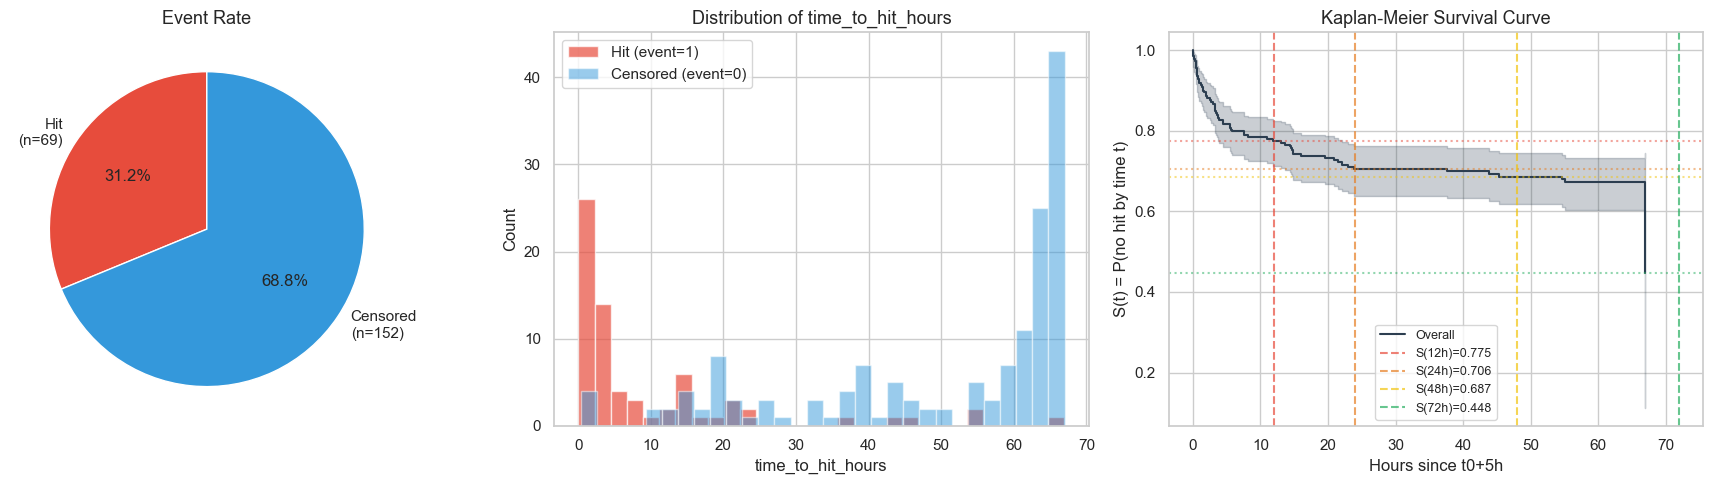

KM survival probabilities:
  S(12h) = 0.7753  =>  Avg P(hit by 12h) = 0.2247
  S(24h) = 0.7056  =>  Avg P(hit by 24h) = 0.2944
  S(48h) = 0.6866  =>  Avg P(hit by 48h) = 0.3134
  S(72h) = 0.4481  =>  Avg P(hit by 72h) = 0.5519


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- 2a. Event rate pie
axes[0].pie([len(hit), len(cen)], labels=[f'Hit\n(n={len(hit)})', f'Censored\n(n={len(cen)})'],
            autopct='%1.1f%%', colors=['#e74c3c','#3498db'], startangle=90)
axes[0].set_title('Event Rate', fontsize=13)

# --- 2b. Time-to-hit histogram
axes[1].hist(hit.time_to_hit_hours, bins=30, color='#e74c3c', alpha=0.7, label='Hit (event=1)')
axes[1].hist(cen.time_to_hit_hours, bins=30, color='#3498db', alpha=0.5, label='Censored (event=0)')
axes[1].set_xlabel('time_to_hit_hours')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of time_to_hit_hours', fontsize=13)
axes[1].legend()

# --- 2c. Kaplan-Meier curve
kmf = KaplanMeierFitter()
kmf.fit(train['time_to_hit_hours'], event_observed=train['event'], label='Overall')
kmf.plot_survival_function(ax=axes[2], ci_show=True, color='#2c3e50')
for t, color in zip([12, 24, 48, 72], ['#e74c3c','#e67e22','#f1c40f','#27ae60']):
    s = kmf.survival_function_at_times(t).values[0]
    axes[2].axvline(t, ls='--', color=color, alpha=0.7, label=f'S({t}h)={s:.3f}')
    axes[2].axhline(s, ls=':', color=color, alpha=0.5)
axes[2].set_title('Kaplan-Meier Survival Curve', fontsize=13)
axes[2].set_xlabel('Hours since t0+5h')
axes[2].set_ylabel('S(t) = P(no hit by time t)')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('eda_target.png', dpi=150, bbox_inches='tight')
plt.show()

print('KM survival probabilities:')
for t in [12, 24, 48, 72]:
    s = kmf.survival_function_at_times(t).values[0]
    print(f'  S({t}h) = {s:.4f}  =>  Avg P(hit by {t}h) = {1-s:.4f}')

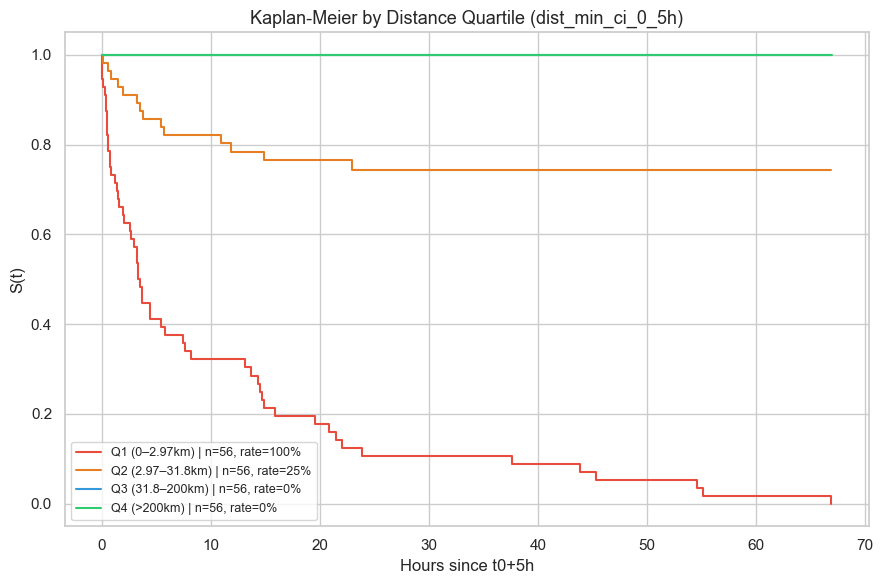

In [7]:
# KM stratified by distance quartile
fig, ax = plt.subplots(figsize=(9, 6))

q = train['dist_min_ci_0_5h'].quantile([0, 0.25, 0.5, 0.75, 1.0])
labels = ['Q1 (0–2.97km)', 'Q2 (2.97–31.8km)', 'Q3 (31.8–200km)', 'Q4 (>200km)']
colors = ['#e74c3c', '#e67e22', '#3498db', '#2ecc71']

for i, (label, color) in enumerate(zip(labels, colors)):
    lo, hi = q.iloc[i], q.iloc[i+1]
    mask = (train['dist_min_ci_0_5h'] >= lo) & (train['dist_min_ci_0_5h'] <= hi)
    sub = train[mask]
    kmf2 = KaplanMeierFitter()
    kmf2.fit(sub['time_to_hit_hours'], event_observed=sub['event'],
             label=f'{label} | n={mask.sum()}, rate={sub.event.mean():.0%}')
    kmf2.plot_survival_function(ax=ax, ci_show=False, color=color)

ax.set_title('Kaplan-Meier by Distance Quartile (dist_min_ci_0_5h)', fontsize=13)
ax.set_xlabel('Hours since t0+5h')
ax.set_ylabel('S(t)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('eda_km_by_distance.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Numeric Feature Profile

In [8]:
profile = train[FEATURES].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T
profile['skew']  = train[FEATURES].skew()
profile['kurt']  = train[FEATURES].kurtosis()
profile['zeros'] = (train[FEATURES] == 0).sum()
profile['zero%'] = (train[FEATURES] == 0).mean().round(3)
profile['neg']   = (train[FEATURES] < 0).sum()
profile[['min','25%','50%','mean','75%','99%','max','std','skew','zero%','neg']]

,min,25%,50%,mean,75%,99%,max,std,skew,zero%,neg
num_perimeters_0_5h,1,1,1,2.063,2,12,17,2.579,3.174,0,0
dt_first_last_0_5h,0,0,0,0.9799,1.356,4.972,4.994,1.738,1.409,0.724,0
low_temporal_resolution_0_5h,0,0,1,0.7285,1,1,1,0.4457,-1.035,0.271,0
area_first_ha,0.03752,25.22,110.1,619.1,485.1,7913,1.194e+04,1448,4.721,0,0
area_growth_abs_0_5h,-2.156e-05,0,0,26.33,0,562.3,2508,187.4,11.23,0.887,1
area_growth_rel_0_5h,-1.438e-07,0,0,0.1789,0,3.29,17.89,1.302,11.95,0.887,1
area_growth_rate_ha_per_h,-5.293e-06,0,0,6.167,0,159.6,520.4,40.47,10.28,0.887,1
log1p_area_first,0.03684,3.266,4.711,4.683,6.186,8.975,9.388,2.084,-0.1115,0,0
log1p_growth,0,0,0,0.3893,0,6.333,7.828,1.34,3.635,0.891,0
log_area_ratio_0_5h,-1.438e-07,0,0,0.06543,0,1.456,2.939,0.3003,6.338,0.887,1


## 4. Zero-Inflation Analysis

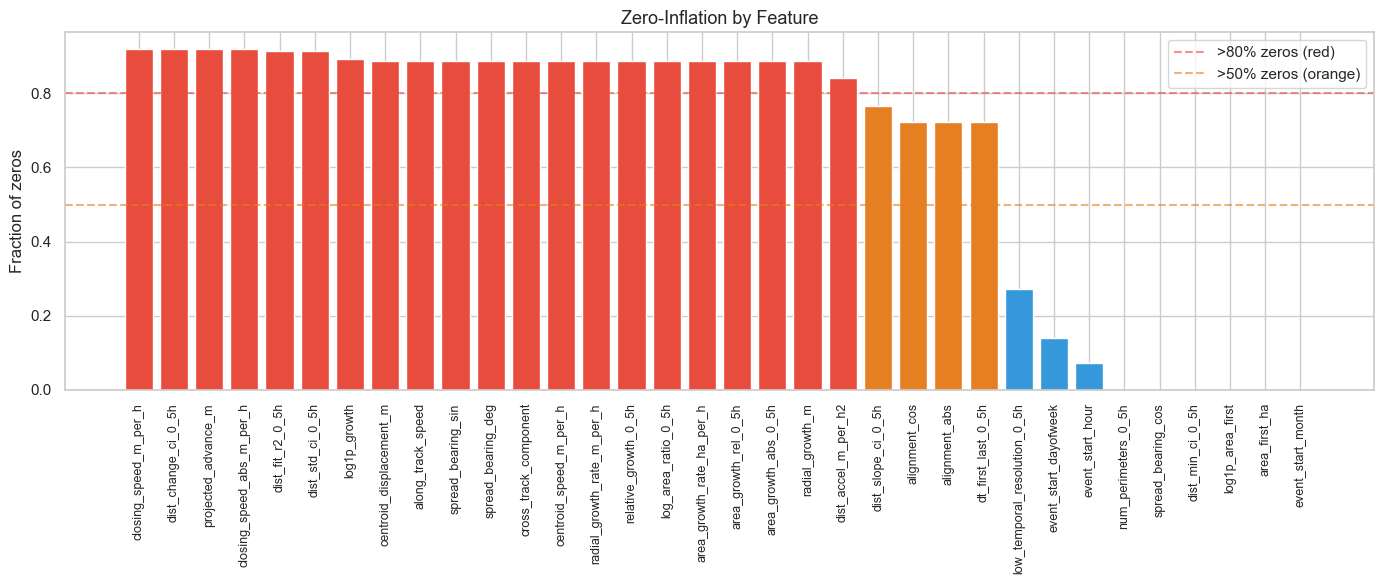

Features with >80% zeros: 21
Features with >50% zeros: 25
Features with NO zeros:   6

Features with no zeros: ['num_perimeters_0_5h', 'spread_bearing_cos', 'dist_min_ci_0_5h', 'log1p_area_first', 'area_first_ha', 'event_start_month']


In [9]:
zero_pct = (train[FEATURES] == 0).mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(range(len(zero_pct)), zero_pct.values,
              color=['#e74c3c' if v > 0.8 else '#e67e22' if v > 0.5 else '#3498db' for v in zero_pct.values])
ax.axhline(0.8, ls='--', color='#e74c3c', alpha=0.6, label='>80% zeros (red)')
ax.axhline(0.5, ls='--', color='#e67e22', alpha=0.6, label='>50% zeros (orange)')
ax.set_xticks(range(len(zero_pct)))
ax.set_xticklabels(zero_pct.index, rotation=90, fontsize=9)
ax.set_ylabel('Fraction of zeros')
ax.set_title('Zero-Inflation by Feature', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('eda_zero_inflation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Features with >80% zeros: {(zero_pct > 0.8).sum()}')
print(f'Features with >50% zeros: {(zero_pct > 0.5).sum()}')
print(f'Features with NO zeros:   {(zero_pct == 0).sum()}')
print(f'\nFeatures with no zeros: {zero_pct[zero_pct == 0].index.tolist()}')

In [10]:
# Root cause: low_temporal_resolution
lt = train['low_temporal_resolution_0_5h']
print('low_temporal_resolution_0_5h breakdown:')
print(f'  low_temp=1 (single perimeter / dt<0.5h): {(lt==1).sum()} fires ({(lt==1).mean():.1%})  -> event rate: {train[lt==1].event.mean():.2%}')
print(f'  low_temp=0 (multiple perimeters, dt≥0.5h): {(lt==0).sum()} fires ({(lt==0).mean():.1%})  -> event rate: {train[lt==0].event.mean():.2%}')
print()
zero_grow = train['area_growth_abs_0_5h'] == 0
print(f'Zero-growth fires:  {zero_grow.sum()}, event rate: {train[zero_grow].event.mean():.2%}')
print(f'Non-zero growth:    {(~zero_grow).sum()}, event rate: {train[~zero_grow].event.mean():.2%}')

low_temporal_resolution_0_5h breakdown:
  low_temp=1 (single perimeter / dt<0.5h): 161 fires (72.9%)  -> event rate: 20.50%
  low_temp=0 (multiple perimeters, dt≥0.5h): 60 fires (27.1%)  -> event rate: 60.00%

Zero-growth fires:  196, event rate: 26.02%
Non-zero growth:    25, event rate: 72.00%


## 5. Hit vs Censored: Group Statistics

In [11]:
rows = []
for f in FEATURES:
    hm = hit[f].mean()
    cm = cen[f].mean()
    r  = train[f].corr(train['event'])
    _, p = stats.mannwhitneyu(hit[f], cen[f], alternative='two-sided')
    rows.append({'Feature': f, 'Hit Mean': hm, 'Cen Mean': cm,
                 'Ratio (hit/cen)': hm/cm if cm != 0 else np.nan,
                 'Pearson r': r, 'MW p-value': p,
                 'Sig': '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else ''))})

grp_stats = pd.DataFrame(rows).sort_values('Pearson r', key=abs, ascending=False)
grp_stats

,Feature,Hit Mean,Cen Mean,Ratio (hit/cen),Pearson r,MW p-value,Sig
18,dist_min_ci_0_5h,2286,1.798e+05,0.01271,-0.4814,1.13e-32,***
2,low_temporal_resolution_0_5h,0.4783,0.8421,0.5679,-0.3791,1.89e-08,***
0,num_perimeters_0_5h,3.478,1.421,2.448,0.3705,1.051e-09,***
1,dt_first_last_0_5h,1.888,0.5675,3.327,0.353,1.289e-08,***
28,alignment_abs,0.3429,0.09544,3.593,0.3491,1.356e-08,***
17,spread_bearing_cos,0.722,0.9669,0.7467,-0.3232,1.938e-06,***
8,log1p_growth,0.9703,0.1256,7.724,0.2927,7.81e-06,***
15,spread_bearing_deg,33.21,4.949,6.709,0.281,2.146e-06,***
9,log_area_ratio_0_5h,0.1674,0.01914,8.749,0.2293,4.451e-05,***
12,radial_growth_rate_m_per_h,19.82,2.302,8.607,0.215,4.451e-05,***


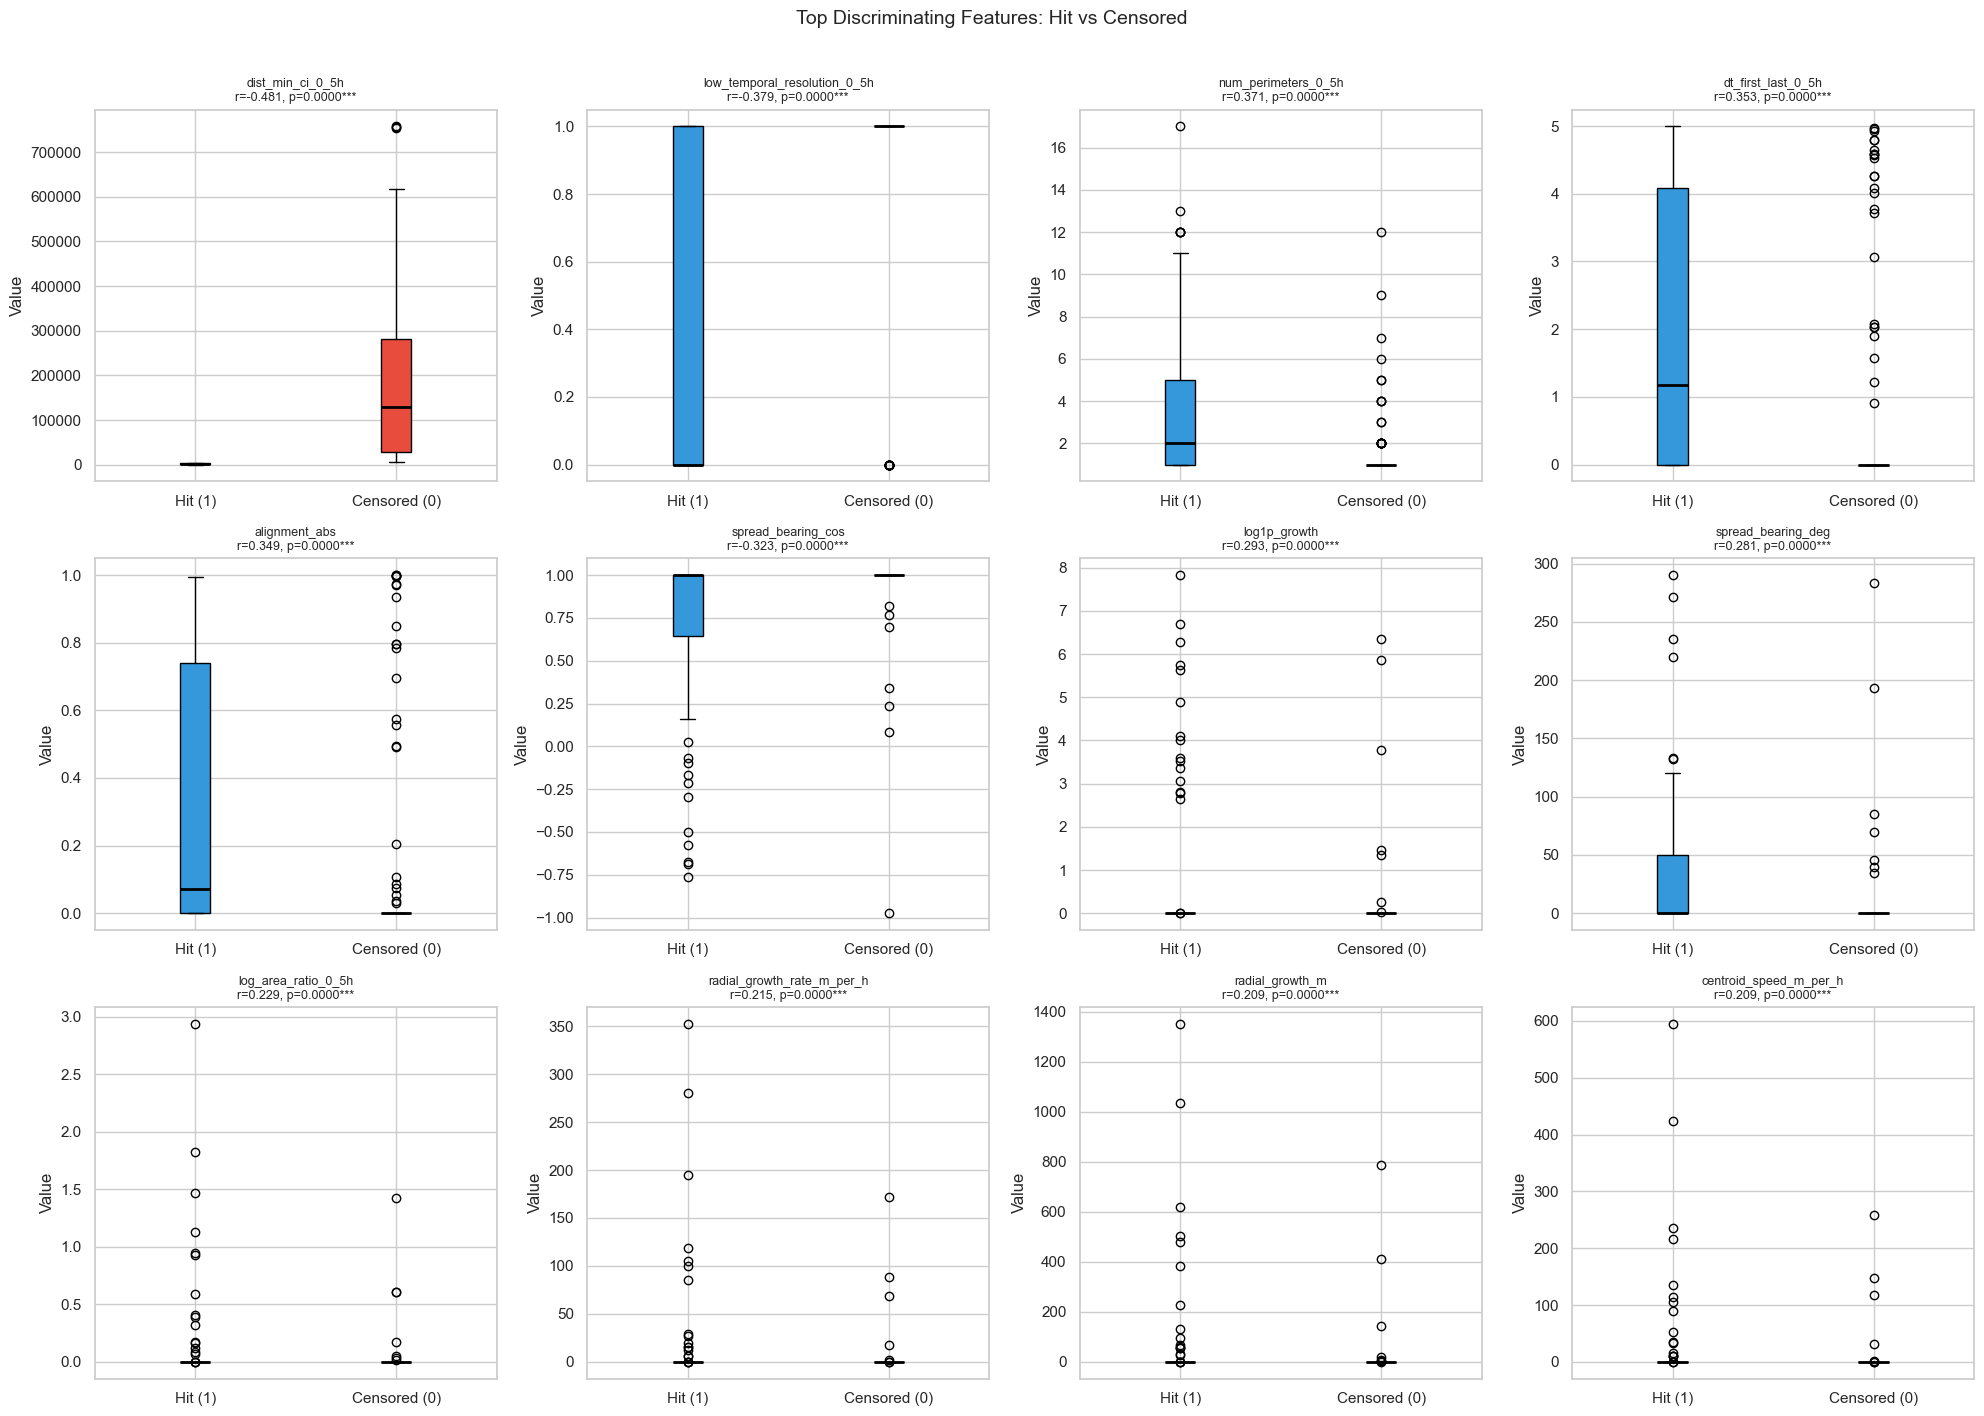

In [12]:
# Visualize top discriminating features as boxplots
top_feats = grp_stats[grp_stats['MW p-value'] < 0.05]['Feature'].head(12).tolist()

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()

for i, f in enumerate(top_feats):
    data_hit = hit[f]
    data_cen = cen[f]
    axes[i].boxplot([data_hit, data_cen], labels=['Hit (1)', 'Censored (0)'],
                    patch_artist=True,
                    boxprops=dict(facecolor='#e74c3c' if i==0 else '#3498db'),
                    medianprops=dict(color='black', linewidth=2))
    row = grp_stats[grp_stats.Feature == f].iloc[0]
    axes[i].set_title(f'{f}\nr={row["Pearson r"]:.3f}, p={row["MW p-value"]:.4f}{row["Sig"]}', fontsize=9)
    axes[i].set_ylabel('Value')

plt.suptitle('Top Discriminating Features: Hit vs Censored', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('eda_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. The Distance Feature in Detail

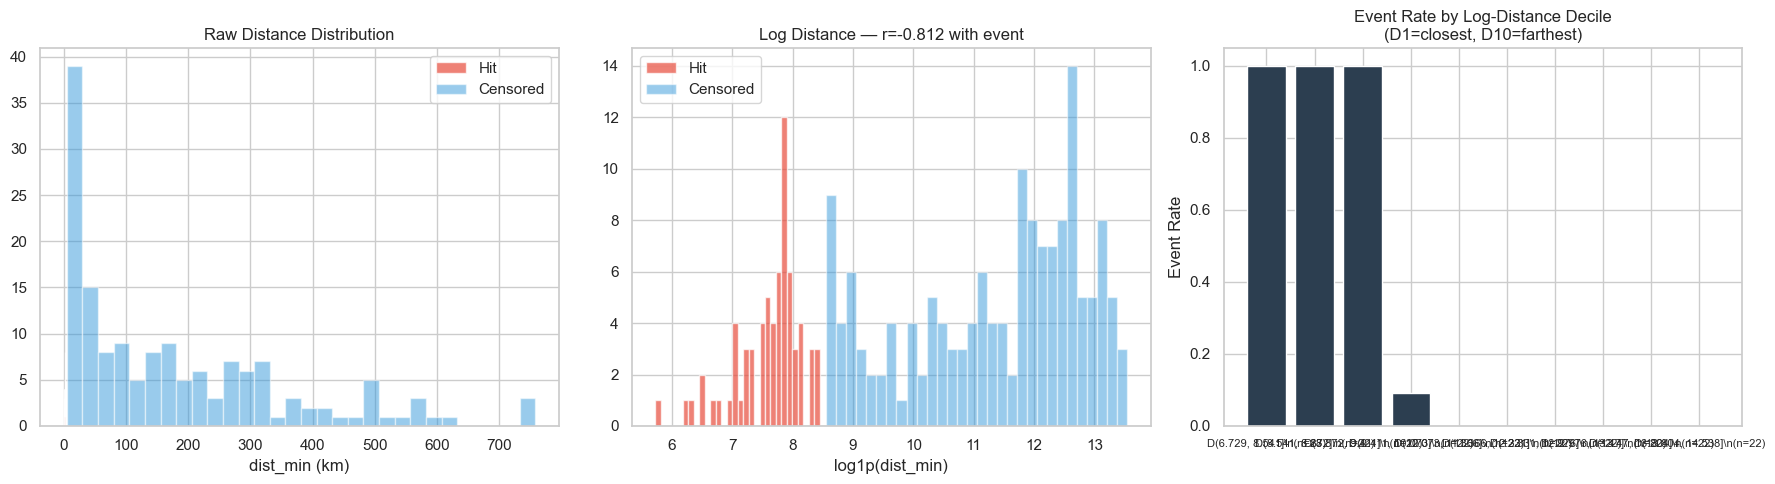

Pearson r (raw distance vs event):  -0.4814
Pearson r (log distance vs event):  -0.8115  <-- massive improvement

Fires within 5km: 69 — event rate: 100%


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 6a. Raw distance by event
axes[0].hist(hit['dist_min_ci_0_5h']/1000, bins=30, color='#e74c3c', alpha=0.7, label='Hit')
axes[0].hist(cen['dist_min_ci_0_5h']/1000, bins=30, color='#3498db', alpha=0.5, label='Censored')
axes[0].set_xlabel('dist_min (km)')
axes[0].set_title('Raw Distance Distribution', fontsize=12)
axes[0].legend()

# 6b. Log distance by event
axes[1].hist(np.log1p(hit['dist_min_ci_0_5h']), bins=30, color='#e74c3c', alpha=0.7, label='Hit')
axes[1].hist(np.log1p(cen['dist_min_ci_0_5h']), bins=30, color='#3498db', alpha=0.5, label='Censored')
r_log = np.log1p(train['dist_min_ci_0_5h']).corr(train['event'])
axes[1].set_xlabel('log1p(dist_min)')
axes[1].set_title(f'Log Distance — r={r_log:.3f} with event', fontsize=12)
axes[1].legend()

# 6c. Event rate by log-distance decile
train['log_dist'] = np.log1p(train['dist_min_ci_0_5h'])
deciles = pd.qcut(train['log_dist'], q=10, duplicates='drop')
rate_by_decile = train.groupby(deciles)['event'].agg(['mean','count'])
axes[2].bar(range(len(rate_by_decile)), rate_by_decile['mean'], color='#2c3e50')
axes[2].set_xticks(range(len(rate_by_decile)))
# axes[2].set_xticklabels([f'D{i+1}\n(n={int(r.count)})' for i, r in rate_by_decile.iterrows()], fontsize=8)
axes[2].set_xticklabels([f'D{i+1}\\n(n={int(r["count"])})' for i, r in rate_by_decile.iterrows()], fontsize=8)
axes[2].set_ylabel('Event Rate')
axes[2].set_title('Event Rate by Log-Distance Decile\n(D1=closest, D10=farthest)', fontsize=12)

plt.tight_layout()
plt.savefig('eda_distance_detail.png', dpi=150, bbox_inches='tight')
plt.show()

train.drop(columns=['log_dist'], inplace=True)

raw_r = train['dist_min_ci_0_5h'].corr(train['event'])
log_r = np.log1p(train['dist_min_ci_0_5h']).corr(train['event'])
print(f'Pearson r (raw distance vs event):  {raw_r:.4f}')
print(f'Pearson r (log distance vs event):  {log_r:.4f}  <-- massive improvement')
under5 = (train['dist_min_ci_0_5h'] < 5000)
print(f'\nFires within 5km: {under5.sum()} — event rate: {train[under5].event.mean():.0%}')

## 7. Redundancy Analysis

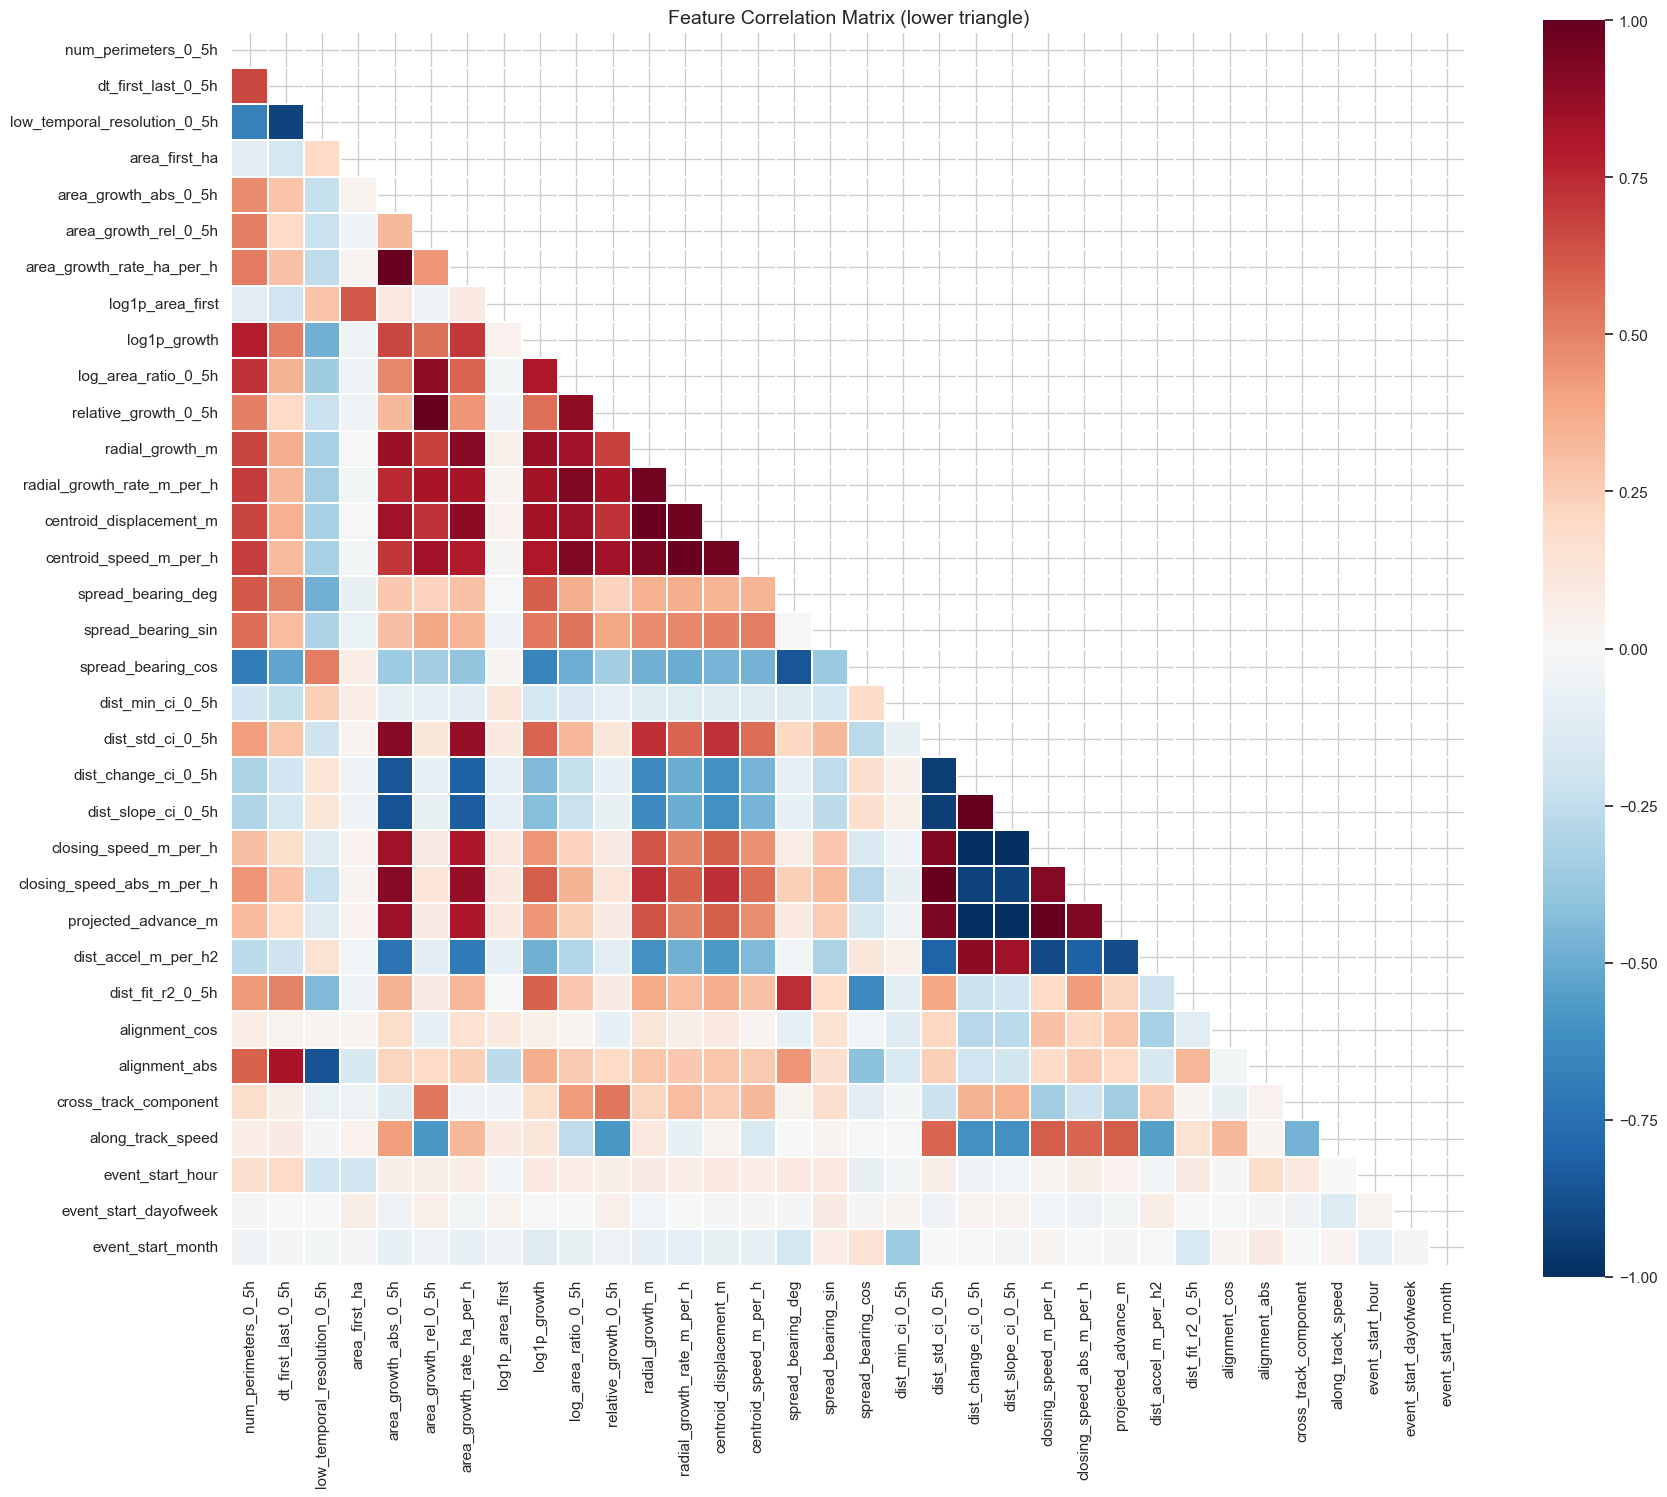

In [19]:
corr_matrix = train[FEATURES].corr()

fig, ax = plt.subplots(figsize=(18, 15))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', vmin=-1, vmax=1,
            ax=ax, linewidths=0.3, annot=False, square=True)
ax.set_title('Feature Correlation Matrix (lower triangle)', fontsize=14)
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# High correlation pairs
upper = corr_matrix.abs().where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_pairs = [(upper.index[i], upper.columns[j], upper.iloc[i,j])
              for i in range(len(upper.index))
              for j in range(len(upper.columns))
              if upper.iloc[i,j] > 0.85]
high_pairs.sort(key=lambda x: -x[2])

print(f'Pairs with |r| > 0.85: {len(high_pairs)}')
print(f'\n{"Feature A":<40} {"Feature B":<40} {"r":>6}')
print('-' * 90)
for a, b, r in high_pairs:
    print(f'{a:<40} {b:<40} {r:>6.4f}')

Pairs with |r| > 0.85: 46

Feature A                                Feature B                                     r
------------------------------------------------------------------------------------------
area_growth_rel_0_5h                     relative_growth_0_5h                     1.0000
dist_change_ci_0_5h                      projected_advance_m                      1.0000
dist_change_ci_0_5h                      closing_speed_m_per_h                    0.9982
closing_speed_m_per_h                    projected_advance_m                      0.9982
dist_std_ci_0_5h                         closing_speed_abs_m_per_h                0.9969
dist_slope_ci_0_5h                       closing_speed_m_per_h                    0.9931
dist_slope_ci_0_5h                       projected_advance_m                      0.9931
dist_change_ci_0_5h                      dist_slope_ci_0_5h                       0.9931
area_growth_abs_0_5h                     area_growth_rate_ha_per_h               

In [21]:
# Redundancy groups at r > 0.97
THRESHOLD = 0.97
corr_abs = corr_matrix.abs()
groups = []
visited = set()
for f in FEATURES:
    if f in visited:
        continue
    group = [f]
    visited.add(f)
    for g in FEATURES:
        if g not in visited and corr_abs.loc[f, g] > THRESHOLD:
            group.append(g)
            visited.add(g)
    if len(group) > 1:
        groups.append(group)

print(f'Near-duplicate groups (|r| > {THRESHOLD}):')
for i, g in enumerate(groups, 1):
    print(f'  Group {i}: {g}')

Near-duplicate groups (|r| > 0.97):
  Group 1: ['area_growth_abs_0_5h', 'area_growth_rate_ha_per_h']
  Group 2: ['area_growth_rel_0_5h', 'relative_growth_0_5h']
  Group 3: ['radial_growth_m', 'centroid_displacement_m']
  Group 4: ['radial_growth_rate_m_per_h', 'centroid_speed_m_per_h']
  Group 5: ['dist_std_ci_0_5h', 'closing_speed_abs_m_per_h']
  Group 6: ['dist_change_ci_0_5h', 'dist_slope_ci_0_5h', 'closing_speed_m_per_h', 'projected_advance_m']


## 8. Feature Importance: Mutual Information & Correlation

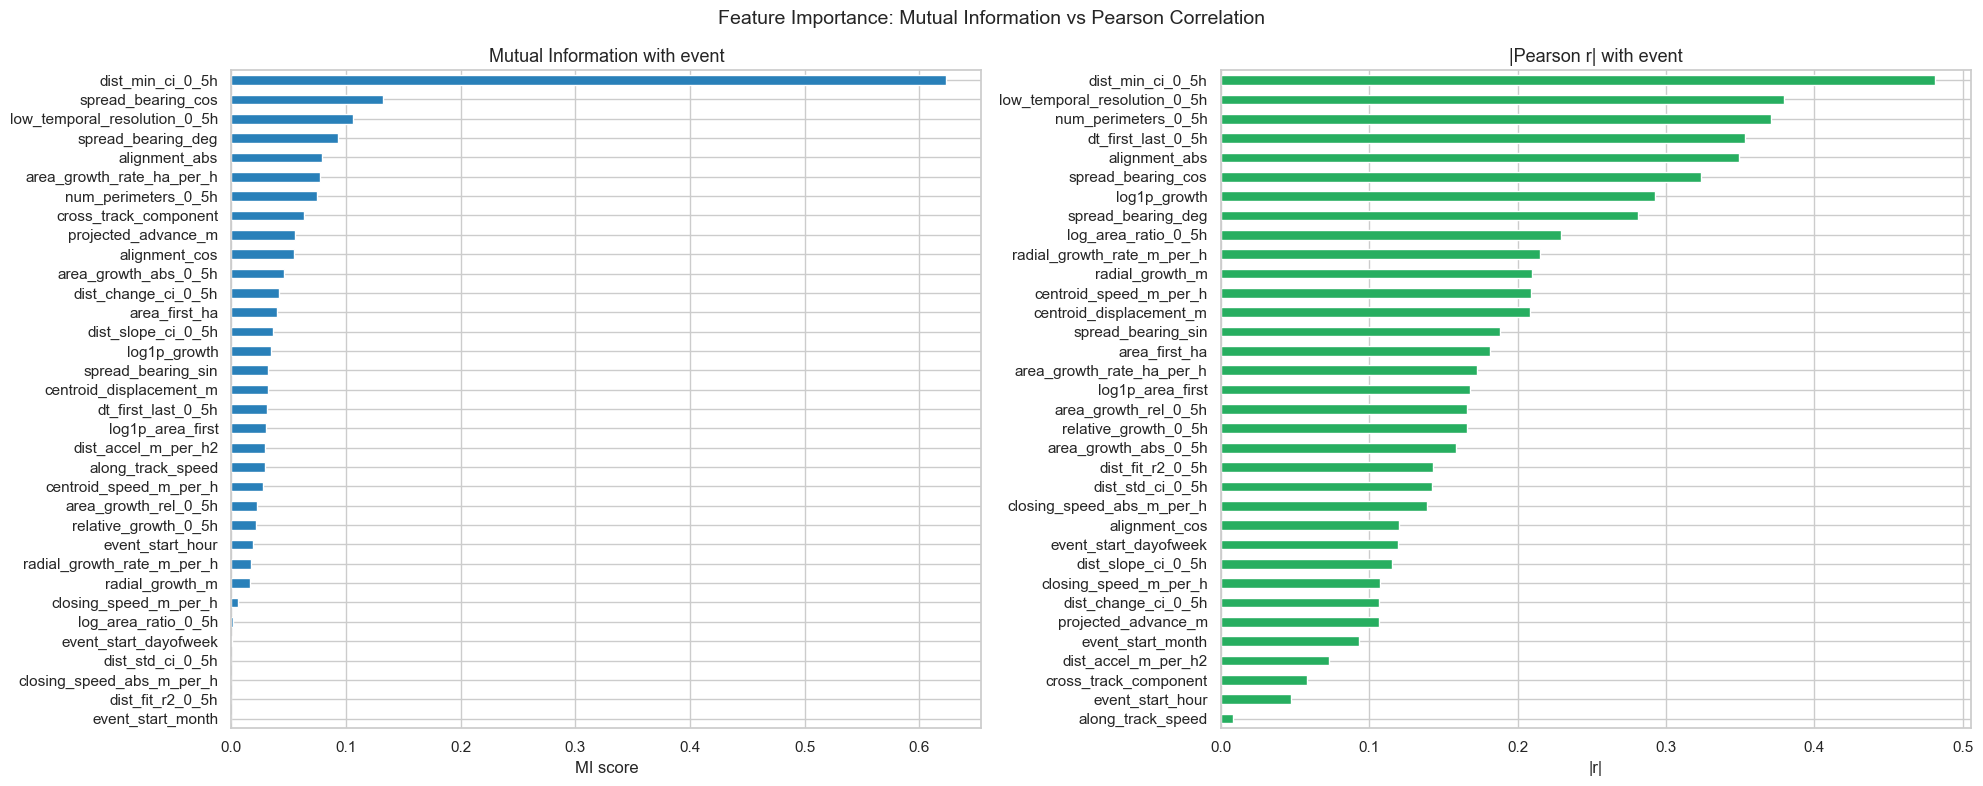

Top 15 by MI:
dist_min_ci_0_5h               0.6231
spread_bearing_cos              0.132
low_temporal_resolution_0_5h   0.1057
spread_bearing_deg             0.0928
alignment_abs                  0.0792
area_growth_rate_ha_per_h      0.0768
num_perimeters_0_5h            0.0743
cross_track_component           0.063
projected_advance_m            0.0553
alignment_cos                  0.0542
area_growth_abs_0_5h           0.0459
dist_change_ci_0_5h            0.0413
area_first_ha                  0.0394
dist_slope_ci_0_5h             0.0362
log1p_growth                   0.0343
dtype: float64

Bottom 10 by MI (candidates to drop):
event_start_hour             0.0185
radial_growth_rate_m_per_h   0.0172
radial_growth_m              0.0163
closing_speed_m_per_h        0.0059
log_area_ratio_0_5h          0.0009
event_start_dayofweek        0.0006
dist_std_ci_0_5h                  0
closing_speed_abs_m_per_h         0
dist_fit_r2_0_5h                  0
event_start_month                 0
dt

In [22]:
mi = mutual_info_classif(train[FEATURES].fillna(0), train['event'], random_state=SEED)
mi_df = pd.Series(mi, index=FEATURES).sort_values(ascending=False)

pearson_r = train[FEATURES].corrwith(train['event']).abs().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Mutual information
mi_df.plot(kind='barh', ax=axes[0], color='#2980b9')
axes[0].set_title('Mutual Information with event', fontsize=13)
axes[0].set_xlabel('MI score')
axes[0].invert_yaxis()

# Pearson r
pearson_r.plot(kind='barh', ax=axes[1], color='#27ae60')
axes[1].set_title('|Pearson r| with event', fontsize=13)
axes[1].set_xlabel('|r|')
axes[1].invert_yaxis()

plt.suptitle('Feature Importance: Mutual Information vs Pearson Correlation', fontsize=14)
plt.tight_layout()
plt.savefig('eda_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 15 by MI:')
print(mi_df.head(15).round(4))
print('\nBottom 10 by MI (candidates to drop):')
print(mi_df.tail(10).round(4))

## 9. Train vs Test Distribution Check

In [23]:
shift_rows = []
for f in FEATURES:
    ks, p = stats.ks_2samp(train[f], test[f])
    shift_rows.append({'Feature': f,
                       'Train Mean': train[f].mean(),
                       'Test Mean':  test[f].mean(),
                       'KS stat': ks,
                       'KS p-value': p,
                       'Shift?': 'YES' if p < 0.05 else ''})

shift_df = pd.DataFrame(shift_rows).sort_values('KS p-value')
print('Any distribution shift (KS p < 0.05)?')
print(shift_df[shift_df['Shift?'] == 'YES'][['Feature','Train Mean','Test Mean','KS p-value']])
if shift_df['Shift?'].eq('YES').sum() == 0:
    print('  None detected — train and test look well-matched.')

shift_df

Any distribution shift (KS p < 0.05)?
Empty DataFrame
Columns: [Feature, Train Mean, Test Mean, KS p-value]
Index: []
  None detected — train and test look well-matched.


,Feature,Train Mean,Test Mean,KS stat,KS p-value,Shift?
32,event_start_dayofweek,2.842,2.547,0.1091,0.3747,
18,dist_min_ci_0_5h,1.244e+05,1.132e+05,0.08545,0.6759,
28,alignment_abs,0.1727,0.128,0.07278,0.8414,
25,dist_accel_m_per_h2,-0.9679,-1.745,0.0664,0.9074,
31,event_start_hour,15.43,14.61,0.0624,0.9396,
1,dt_first_last_0_5h,0.9799,0.8323,0.06097,0.9493,
21,dist_slope_ci_0_5h,-3.031,-0.7691,0.0604,0.9532,
0,num_perimeters_0_5h,2.063,1.926,0.05754,0.9688,
3,area_first_ha,619.1,891.3,0.05706,0.9705,
7,log1p_area_first,4.683,4.767,0.05706,0.9705,


## 10. Feature Interaction Analysis

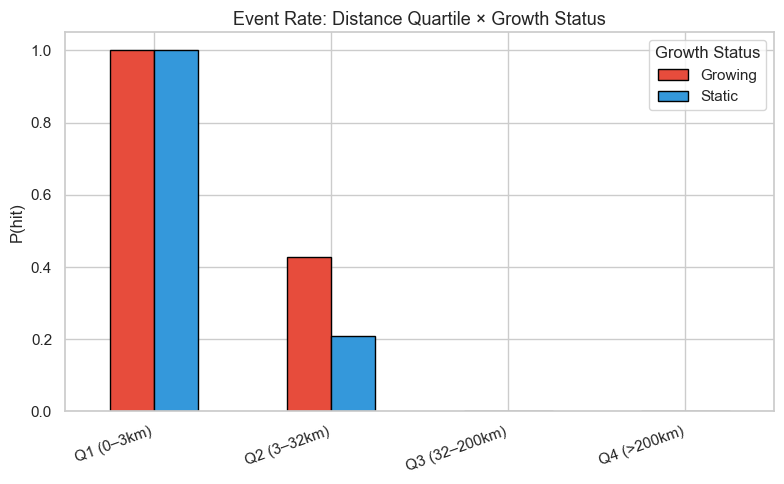

Event rate by distance quartile x growth status:
area_growth_abs_0_5h  Growing  Static
dist_min_ci_0_5h                     
Q1 (0–3km)                  1       1
Q2 (3–32km)             0.429   0.208
Q3 (32–200km)               0       0
Q4 (>200km)                 0       0


In [24]:
# Event rate by distance quartile x growth status
bins_d = pd.qcut(train['dist_min_ci_0_5h'], q=4, labels=['Q1 (0–3km)','Q2 (3–32km)','Q3 (32–200km)','Q4 (>200km)'])
bins_g = (train['area_growth_abs_0_5h'] > 0).map({True:'Growing', False:'Static'})
ct = pd.crosstab(bins_d, bins_g, values=train['event'], aggfunc='mean').round(3)

fig, ax = plt.subplots(figsize=(8, 5))
ct.plot(kind='bar', ax=ax, color=['#e74c3c','#3498db'], edgecolor='black')
ax.set_title('Event Rate: Distance Quartile × Growth Status', fontsize=13)
ax.set_ylabel('P(hit)')
ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.legend(title='Growth Status')
plt.tight_layout()
plt.savefig('eda_interaction_dist_growth.png', dpi=150, bbox_inches='tight')
plt.show()

print('Event rate by distance quartile x growth status:')
print(ct)

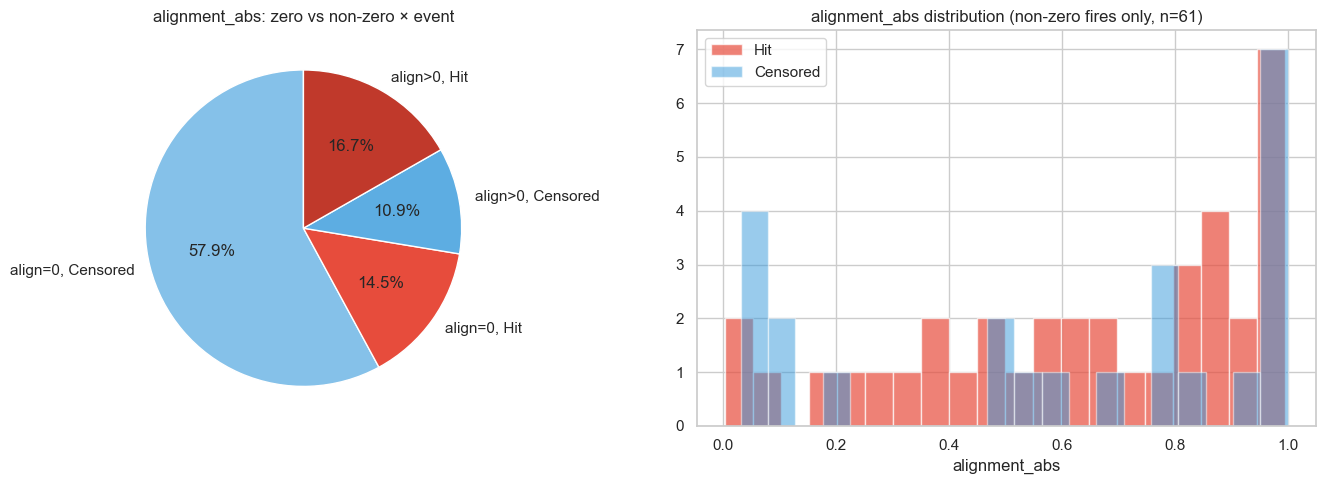

alignment_abs = 0: n=160, event rate = 20.00%
alignment_abs > 0: n=61, event rate = 60.66%


In [25]:
# Alignment_abs deep dive
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mask0 = train['alignment_abs'] == 0
mask1 = train['alignment_abs'] > 0

# Pie: zeros vs non-zeros
axes[0].pie([(mask0 & (train.event==0)).sum(), (mask0 & (train.event==1)).sum(),
             (mask1 & (train.event==0)).sum(), (mask1 & (train.event==1)).sum()],
            labels=['align=0, Censored', 'align=0, Hit', 'align>0, Censored', 'align>0, Hit'],
            colors=['#85c1e9','#e74c3c','#5dade2','#c0392b'],
            autopct='%1.1f%%', startangle=90)
axes[0].set_title('alignment_abs: zero vs non-zero × event', fontsize=12)

# Histogram among non-zero fires
sub = train[mask1]
axes[1].hist(sub[sub.event==1]['alignment_abs'], bins=20, color='#e74c3c', alpha=0.7, label='Hit')
axes[1].hist(sub[sub.event==0]['alignment_abs'], bins=20, color='#3498db', alpha=0.5, label='Censored')
axes[1].set_title(f'alignment_abs distribution (non-zero fires only, n={mask1.sum()})', fontsize=12)
axes[1].set_xlabel('alignment_abs')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_alignment.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'alignment_abs = 0: n={mask0.sum()}, event rate = {train[mask0].event.mean():.2%}')
print(f'alignment_abs > 0: n={mask1.sum()}, event rate = {train[mask1].event.mean():.2%}')

## 11. Proposed Engineered Features

In [26]:
eps = 1e-6
eng_features = {
    'log1p_dist_min':       np.log1p(train['dist_min_ci_0_5h']),
    'dist_under_5km':       (train['dist_min_ci_0_5h'] < 5000).astype(int),
    'is_growing':           (train['area_growth_abs_0_5h'] > 0).astype(int),
    'speed_x_alignment':    train['radial_growth_rate_m_per_h'] * train['alignment_abs'],
    'tti_proxy':            train['dist_min_ci_0_5h'] / (train['closing_speed_abs_m_per_h'].clip(lower=0) + eps),
    'close_x_align':        train['closing_speed_abs_m_per_h'] * train['alignment_abs'],
}

print(f'{"Engineered Feature":<25} {"Pearson r":>10} {"MW p-value":>12}')
print('-' * 52)
for name, series in eng_features.items():
    r = series.corr(train['event'])
    _, p = stats.mannwhitneyu(series[train.event==1], series[train.event==0], alternative='two-sided')
    star = '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else ''))
    print(f'{name:<25} {r:>10.4f} {p:>12.6f} {star}')

Engineered Feature         Pearson r   MW p-value
----------------------------------------------------
log1p_dist_min               -0.8115     0.000000 ***
dist_under_5km                1.0000     0.000000 ***
is_growing                    0.2984     0.000010 ***
speed_x_alignment             0.2042     0.000039 ***
tti_proxy                    -0.4725     0.000000 ***
close_x_align                 0.1343     0.003698 **


## 12. Feature Selection Summary

In [27]:
print('=== STEP 1: Remove exact/near-duplicates (keep one per group) ===')
to_drop_redundant = [
    'relative_growth_0_5h',      # exact duplicate of area_growth_rel_0_5h (r=1.000)
    'area_growth_rate_ha_per_h',  # r=0.991 with area_growth_abs_0_5h
    'centroid_displacement_m',    # r=0.989 with radial_growth_m
    'centroid_speed_m_per_h',     # r=0.989 with radial_growth_rate_m_per_h
    'closing_speed_m_per_h',      # cluster with dist_change_ci_0_5h (r>0.99)
    'projected_advance_m',        # cluster with dist_change_ci_0_5h (r>0.99)
    'dist_slope_ci_0_5h',         # cluster with dist_change_ci_0_5h (r>0.99)
    'closing_speed_abs_m_per_h',  # r=0.997 with dist_std_ci_0_5h
]
print(f'Dropping {len(to_drop_redundant)} redundant features: {to_drop_redundant}')

print('\n=== STEP 2: Drop non-significant noise features ===')
to_drop_noise = [
    'event_start_hour',      # p=0.83, MI=0.019
    'event_start_dayofweek', # p=0.08, MI=0.001
    'event_start_month',     # p=0.28, MI=0.000
    'along_track_speed',     # p=0.35, MI lowest
    'cross_track_component', # p=0.07, MI low
    'dist_accel_m_per_h2',   # p=0.18, MI low
]
print(f'Dropping {len(to_drop_noise)} noise features: {to_drop_noise}')

remaining = [f for f in FEATURES if f not in to_drop_redundant + to_drop_noise]
print(f'\nRemaining: {len(remaining)} features')
print(remaining)

print('\n=== STEP 3: Add engineered features ===')
new_features = ['log1p_dist_min', 'dist_under_5km', 'is_growing', 'speed_x_alignment', 'log1p_dist_min']
print(f'Adding: {list(eng_features.keys())}')
print(f'\nFinal feature count (before model-level selection): {len(remaining) + len(eng_features)} features')

=== STEP 1: Remove exact/near-duplicates (keep one per group) ===
Dropping 8 redundant features: ['relative_growth_0_5h', 'area_growth_rate_ha_per_h', 'centroid_displacement_m', 'centroid_speed_m_per_h', 'closing_speed_m_per_h', 'projected_advance_m', 'dist_slope_ci_0_5h', 'closing_speed_abs_m_per_h']

=== STEP 2: Drop non-significant noise features ===
Dropping 6 noise features: ['event_start_hour', 'event_start_dayofweek', 'event_start_month', 'along_track_speed', 'cross_track_component', 'dist_accel_m_per_h2']

Remaining: 20 features
['num_perimeters_0_5h', 'dt_first_last_0_5h', 'low_temporal_resolution_0_5h', 'area_first_ha', 'area_growth_abs_0_5h', 'area_growth_rel_0_5h', 'log1p_area_first', 'log1p_growth', 'log_area_ratio_0_5h', 'radial_growth_m', 'radial_growth_rate_m_per_h', 'spread_bearing_deg', 'spread_bearing_sin', 'spread_bearing_cos', 'dist_min_ci_0_5h', 'dist_std_ci_0_5h', 'dist_change_ci_0_5h', 'dist_fit_r2_0_5h', 'alignment_cos', 'alignment_abs']

=== STEP 3: Add engine

## 13. Outlier Detection

In [28]:
# Note: z-score outlier detection is unreliable on zero-inflated features.
# Use IQR method instead for meaningful outlier detection.
outlier_summary = []
for f in FEATURES:
    Q1 = train[f].quantile(0.25)
    Q3 = train[f].quantile(0.75)
    IQR = Q3 - Q1
    if IQR == 0:
        continue
    lo, hi = Q1 - 3*IQR, Q3 + 3*IQR
    n_out = ((train[f] < lo) | (train[f] > hi)).sum()
    if n_out > 0:
        outlier_summary.append({'Feature': f, 'Outliers (3xIQR)': n_out,
                                 'Pct': f'{100*n_out/len(train):.1f}%',
                                 'Max': train[f].max(), 'Min': train[f].min()})

out_df = pd.DataFrame(outlier_summary).sort_values('Outliers (3xIQR)', ascending=False)
print('Features with extreme outliers (3×IQR):')
print(out_df.to_string(index=False))

Features with extreme outliers (3×IQR):
            Feature  Outliers (3xIQR)   Pct       Max     Min
      alignment_abs                48 21.7%         1       0
num_perimeters_0_5h                19  8.6%        17       1
      area_first_ha                17  7.7% 1.194e+04 0.03752


## 14. EDA Summary & Key Takeaways

In [29]:
print("""
╔══════════════════════════════════════════════════════════════════════╗
║               WiDS 2026 — EDA KEY TAKEAWAYS                         ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  1. DISTANCE IS KING (but use log scale)                             ║
║     log1p(dist_min): r = -0.81 vs raw: r = -0.48                    ║
║     All fires within 5km → 100% event rate (69/69 hits)             ║
║                                                                      ║
║  2. ZERO-INFLATION IS STRUCTURAL (not a quality issue)               ║
║     88% of growth/kinematic features are exactly 0                  ║
║     Caused by 73% of fires having only 1 perimeter in 5h window     ║
║     Static fires: 26% event rate | Growing fires: 72% event rate    ║
║                                                                      ║
║  3. SIX NEAR-DUPLICATE FEATURE GROUPS (r > 0.97)                    ║
║     One group is a LITERAL duplicate (r=1.000)                      ║
║     Drop 8 redundant features to reduce multicollinearity           ║
║                                                                      ║
║  4. TEMPORAL METADATA IS NOISE                                       ║
║     hour/day/month: all p > 0.07, MI ≈ 0.000                        ║
║     On 221 samples, these will only hurt calibration                 ║
║                                                                      ║
║  5. TIME-TO-HIT IS FRONT-LOADED                                      ║
║     64% of all hits occur within the first 6 hours                  ║
║     Only 6 fires hit between 24h–72h → thin signal for late windows ║
║                                                                      ║
║  6. NO TRAIN/TEST DISTRIBUTION SHIFT (KS p > 0.05 for all features) ║
║                                                                      ║
║  NEXT STEPS:                                                         ║
║  → Feature engineering (log dist, is_growing, speed×alignment)      ║
║  → Remove 14 drop candidates (8 redundant + 6 noise)                ║
║  → Build modular ensemble: RSF + CoxPH + XGBoost Cox                ║
╚══════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════╗
║               WiDS 2026 — EDA KEY TAKEAWAYS                         ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  1. DISTANCE IS KING (but use log scale)                             ║
║     log1p(dist_min): r = -0.81 vs raw: r = -0.48                    ║
║     All fires within 5km → 100% event rate (69/69 hits)             ║
║                                                                      ║
║  2. ZERO-INFLATION IS STRUCTURAL (not a quality issue)               ║
║     88% of growth/kinematic features are exactly 0                  ║
║     Caused by 73% of fires having only 1 perimeter in 5h window     ║
║     Static fires: 26% event rate | Growing fires: 72% event rate    ║
║                                                                      ║
║  3. SIX NEAR-DUPLICATE FEATURE GROUPS (r > 0.97)      